In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                               precision_recall_curve, roc_auc_score, 
                               f1_score, ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek

In [6]:
data = pd.read_csv('/Users/Downloads/creditcard.csv')
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
data.shape

(284807, 31)

In [8]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
print(data['Class'].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


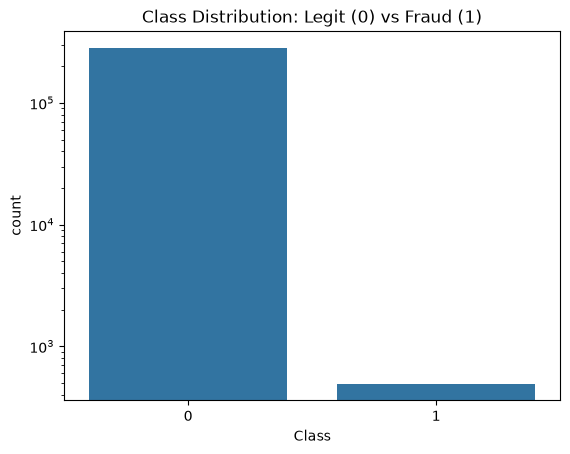

In [11]:
sns.countplot(x='Class', data=data)
plt.title('Class Distribution: Legit (0) vs Fraud (1)')
plt.yscale('log')
plt.show()

In [17]:
data[['Amount', 'Time']].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


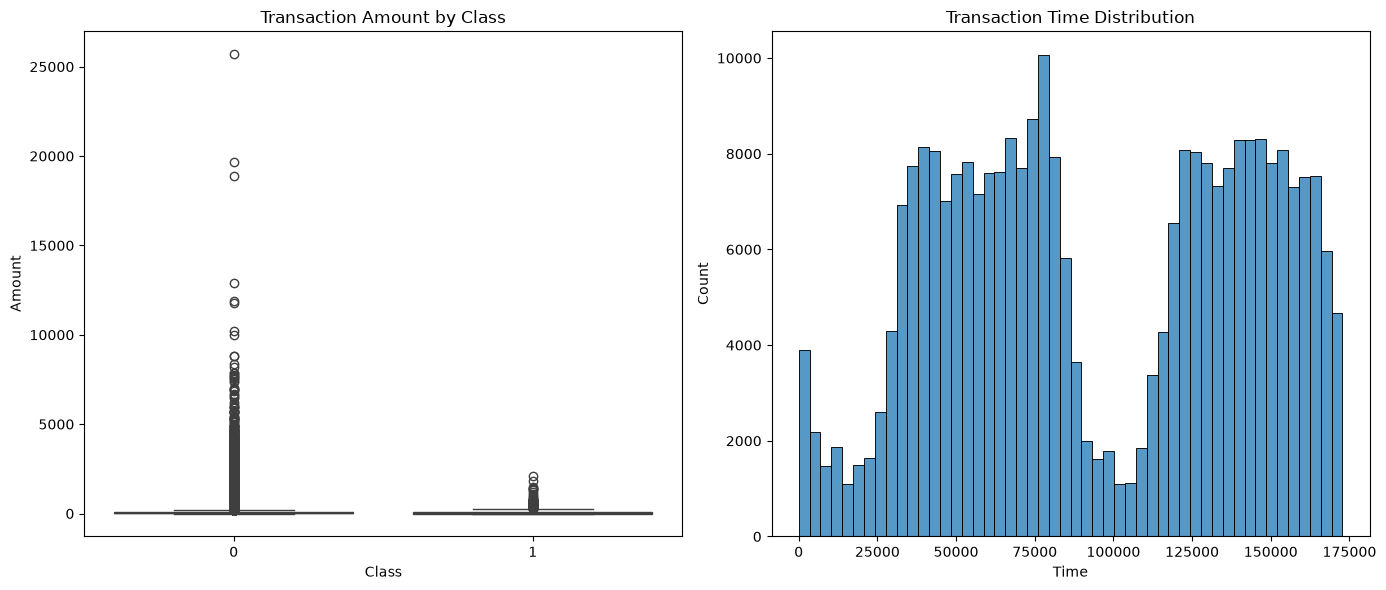

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='Class', y='Amount', data=data, ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
sns.histplot(data['Time'], bins=50, ax=axes[1])
axes[1].set_title('Transaction Time Distribution')
plt.tight_layout()
plt.show()

In [27]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,stratify=y, random_state=42)

print("Train distribution:\n", y_train.value_counts())
print("Test distribution:\n", y_test.value_counts())

Train distribution:
 Class
0    190490
1       330
Name: count, dtype: int64
Test distribution:
 Class
0    93825
1      162
Name: count, dtype: int64


1. Split data (train/test)
2. Pick a model      ─┐
3. Train baseline     ├─ these two can happen in either order relative to each other
   (no balancing)    ─┘
4. Apply SMOTE/ADASYN to training data
5. Retrain the SAME model on balanced data
6. Compare baseline vs balanced

In [30]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("---Baseline (WITHOUT CLASS BALANCING)---")
print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC: ", roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1]))

---Baseline (WITHOUT CLASS BALANCING)---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.87      0.60      0.71       162

    accuracy                           1.00     93987
   macro avg       0.93      0.80      0.86     93987
weighted avg       1.00      1.00      1.00     93987

ROC-AUC:  0.9307808403482976


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 190490, 1: 330}
After SMOTE: {0: 190490, 1: 190490}


In [33]:
smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("---SMOTE---")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC: ", roc_auc_score(y_test, smote_model.predict_proba(X_test)[:,1]))

---SMOTE---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     93825
           1       0.12      0.86      0.21       162

    accuracy                           0.99     93987
   macro avg       0.56      0.93      0.60     93987
weighted avg       1.00      0.99      0.99     93987

ROC-AUC:  0.9642488149398177


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
# ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Before ADASYN:", y_train.value_counts().to_dict())
print("After ADASYN:", y_train_adasyn.value_counts().to_dict())

Before ADASYN: {0: 190490, 1: 330}
After ADASYN: {0: 190490, 1: 190474}


In [38]:
adasyn_model = LogisticRegression(max_iter=1000, random_state=42)
adasyn_model.fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = adasyn_model.predict(X_test)

print("---ADASYN---")
print(classification_report(y_test, y_pred_adasyn))
print("ROC-AUC: ", roc_auc_score(y_test, adasyn_model.predict_proba(X_test)[:,1]))

---ADASYN---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     93825
           1       0.10      0.87      0.18       162

    accuracy                           0.99     93987
   macro avg       0.55      0.93      0.59     93987
weighted avg       1.00      0.99      0.99     93987

ROC-AUC:  0.965901056932232


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
#Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Before Random Undersampling:", y_train.value_counts().to_dict())
print("After Random Undersampling:", y_train_rus.value_counts().to_dict())

Before Random Undersampling: {0: 190490, 1: 330}
After Random Undersampling: {0: 330, 1: 330}


In [55]:
rus_model = LogisticRegression(random_state=42)
rus_model.fit(X_train_rus, y_train_rus)
y_pred_rus = rus_model.predict(X_test)

print("----Random Undersampling---")
print(classification_report(y_test, y_pred_rus))
print("ROC-AUC:", roc_auc_score(y_test, rus_model.predict_proba(X_test)[:, 1]))

----Random Undersampling---
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     93825
           1       0.03      0.88      0.06       162

    accuracy                           0.95     93987
   macro avg       0.52      0.92      0.52     93987
weighted avg       1.00      0.95      0.97     93987

ROC-AUC: 0.9591571187494448


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
#TOMEK
tomek = TomekLinks(sampling_strategy='auto')
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train, y_train)

print("Before TOMEK Undersampling:", y_train.value_counts().to_dict())
print("After TOMEK Undersampling:", y_train_tomek.value_counts().to_dict())

Before TOMEK Undersampling: {0: 190490, 1: 330}
After TOMEK Undersampling: {0: 190441, 1: 330}


In [56]:
tomek_model = LogisticRegression(max_iter=1000, random_state=42)
tomek_model.fit(X_train_tomek, y_train_tomek)
y_pred_tomek = tomek_model.predict(X_test)

print("---TOMEK---")
print(classification_report(y_test, y_pred_tomek))
print("ROC-AUC: ", roc_auc_score(y_test, tomek_model.predict_proba(X_test)[:,1]))

---TOMEK---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.83      0.68      0.75       162

    accuracy                           1.00     93987
   macro avg       0.91      0.84      0.87     93987
weighted avg       1.00      1.00      1.00     93987

ROC-AUC:  0.9355237785080579


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
# SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

print("Before SMOTE + Tomek:", y_train.value_counts().to_dict())
print("After SMOTE + Tomek:", y_train_st.value_counts().to_dict())

Before SMOTE + Tomek: {0: 190490, 1: 330}
After SMOTE + Tomek: {0: 189875, 1: 189875}


In [44]:
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

st_model = RandomForestClassifier(random_state=42)
st_model.fit(X_train_st, y_train_st)
y_pred_st = st_model.predict(X_test)

print("=== SMOTE + Tomek ===")
print(classification_report(y_test, y_pred_st))

=== SMOTE + Tomek ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.88      0.80      0.84       162

    accuracy                           1.00     93987
   macro avg       0.94      0.90      0.92     93987
weighted avg       1.00      1.00      1.00     93987



In [45]:
# Comparing everything
results = {
    'Baseline': (y_test, y_pred_baseline, baseline_model),
    'SMOTE': (y_test, y_pred_smote, smote_model),
    'ADASYN': (y_test, y_pred_adasyn, adasyn_model),
    'Undersampling': (y_test, y_pred_rus, rus_model),
    'SMOTE+Tomek': (y_test, y_pred_st, st_model),
}

comparison = []
for name, (yt, yp, model) in results.items():
    comparison.append({
        'Method': name,
        'Precision (minority)': classification_report(yt, yp, output_dict=True)['1']['precision'],
        'Recall (minority)': classification_report(yt, yp, output_dict=True)['1']['recall'],
        'F1 (minority)': classification_report(yt, yp, output_dict=True)['1']['f1-score'],
        'ROC-AUC': roc_auc_score(yt, model.predict_proba(X_test)[:, 1])
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(3))

          Method  Precision (minority)  Recall (minority)  F1 (minority)  \
0       Baseline                 0.867              0.605          0.713   
1          SMOTE                 0.122              0.864          0.214   
2         ADASYN                 0.101              0.870          0.181   
3  Undersampling                 0.031              0.883          0.061   
4    SMOTE+Tomek                 0.884              0.796          0.838   

   ROC-AUC  
0    0.931  
1    0.964  
2    0.966  
3    0.959  
4    0.963  


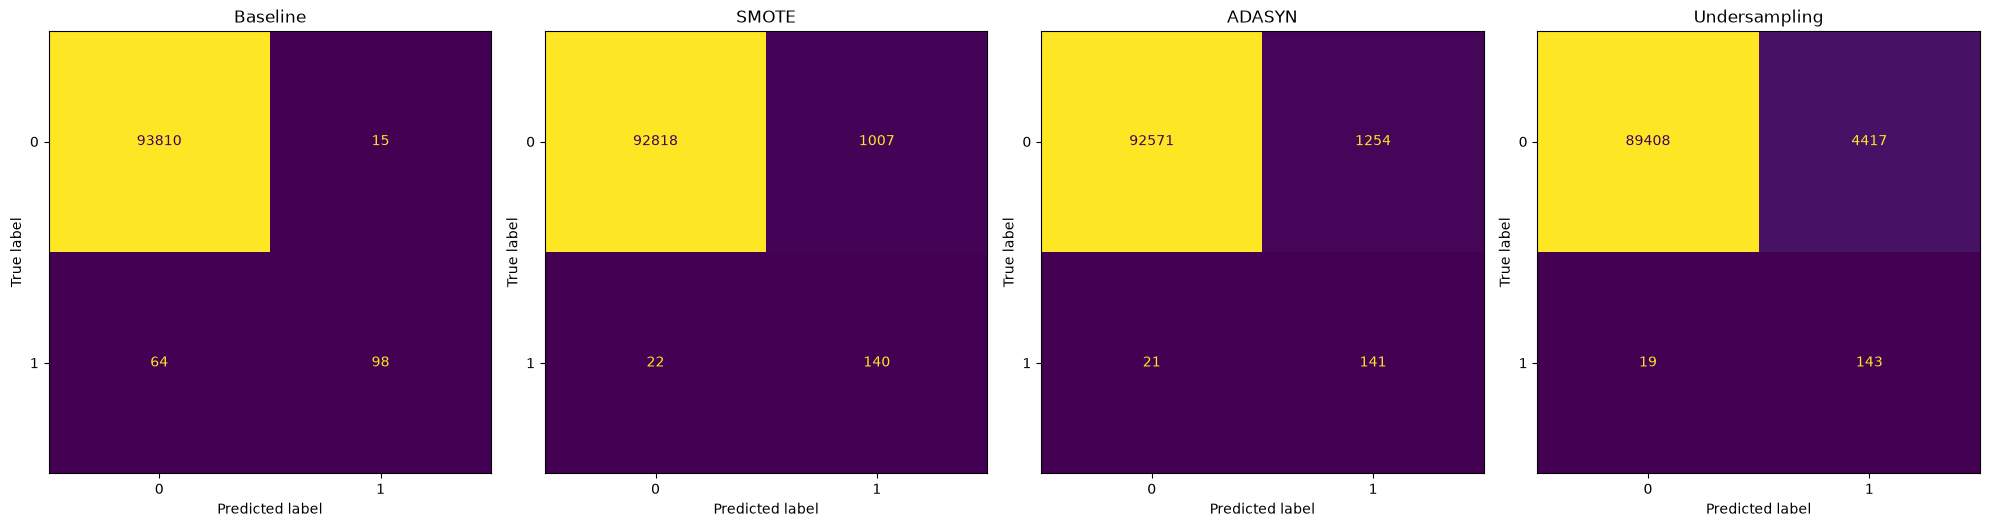

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
for ax, (name, (yt, yp, model)) in zip(axes, list(results.items())[:4]):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()